# Test 4: Noise Replacement Ablation

Replace the quantum circuit output with random noise. If performance is similar,
the circuit's computation doesn't matter — the QuantumHead MLP extracts value from classical context alone.

**Key question:** Does the quantum circuit provide signal beyond random features?

In [1]:
from setup_helpers import *

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
data = load_data()
print("Model and data loaded.")

Model and data loaded.


In [2]:
# First, collect real quantum output stats for matched-noise replacement
real_outputs = []

def hook_collect(module, input, output):
    real_outputs.append(output.detach().cpu().numpy())

h = model.quantum_block.register_forward_hook(hook_collect)
_ = evaluate(model, data.val, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
h.remove()

Q_real = np.concatenate(real_outputs, axis=0)
q_mean = Q_real.mean(axis=0)
q_std = Q_real.std(axis=0)
print(f"Real quantum output stats: mean={q_mean.mean():.4f}, std={q_std.mean():.4f}")

Real quantum output stats: mean=-0.0273, std=0.1969


In [3]:
# Baseline: real quantum
results = {}

# Quantum OFF
results["Quantum OFF"] = evaluate(model, data.val, data.target_scaler, enable_quantum=False)

# Real quantum ON
results["Real Quantum"] = evaluate(model, data.val, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)

print(f"Quantum OFF mRMSE: {results['Quantum OFF']['rmse_mean']:.4f}")
print(f"Real Quantum mRMSE: {results['Real Quantum']['rmse_mean']:.4f}")

Quantum OFF mRMSE: 0.2993
Real Quantum mRMSE: 0.2922


In [4]:
# Noise replacement functions
n_qubits = model_cfg.qnn_qubits
original_forward = model.quantum_block.__class__.forward

def replace_with_uniform(module, inputs):
    """Random uniform [-1, 1] — same range as PauliZ."""
    batch_size = inputs.shape[0]
    return torch.FloatTensor(batch_size, n_qubits).uniform_(-1, 1).to(inputs.device)

def replace_with_matched_noise(module, inputs):
    """Random with same mean/std as real quantum outputs."""
    batch_size = inputs.shape[0]
    noise = torch.randn(batch_size, n_qubits)
    noise = noise * torch.tensor(q_std) + torch.tensor(q_mean)
    return noise.to(inputs.device)

def replace_with_zeros(module, inputs):
    """Constant zeros — no quantum info."""
    batch_size = inputs.shape[0]
    return torch.zeros(batch_size, n_qubits).to(inputs.device)

# Run multiple trials for noise (to average out randomness)
N_TRIALS = 5

for name, replace_fn in [("Uniform Noise", replace_with_uniform),
                          ("Matched Noise", replace_with_matched_noise),
                          ("Zeros", replace_with_zeros)]:
    trial_mrmses = []
    trial_rmses = []
    for trial in range(N_TRIALS if "Noise" in name else 1):
        # Monkey-patch
        model.quantum_block.forward = lambda self_or_input, _fn=replace_fn: _fn(model.quantum_block, self_or_input)
        m = evaluate(model, data.val, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
        trial_mrmses.append(m["rmse_mean"])
        trial_rmses.append(m["rmse_orig"])

    # Restore original
    del model.quantum_block.forward

    avg_mrmse = np.mean(trial_mrmses)
    avg_rmse = np.mean(trial_rmses, axis=0)
    results[name] = {"rmse_mean": avg_mrmse, "mae_mean": 0.0, "rmse_orig": avg_rmse, "mae_orig": np.zeros(5)}
    if len(trial_mrmses) > 1:
        print(f"{name}: mRMSE = {avg_mrmse:.4f} ± {np.std(trial_mrmses):.4f} (over {N_TRIALS} trials)")
    else:
        print(f"{name}: mRMSE = {avg_mrmse:.4f}")

Uniform Noise: mRMSE = 0.2923 ± 0.0000 (over 5 trials)
Matched Noise: mRMSE = 0.2923 ± 0.0000 (over 5 trials)
Zeros: mRMSE = 0.2923


In [5]:
display(compare_table(results))

,mRMSE,mMAE,RMSE H₂O,RMSE CO₂,RMSE CO,RMSE CH₄,RMSE NH₃
Condition,,,,,,,
Quantum OFF,0.2993,0.1831,0.4000,0.2451,0.2235,0.2344,0.3933
Real Quantum,0.2922,0.1787,0.3893,0.2326,0.2205,0.2325,0.3863
Uniform Noise,0.2923,0.0000,0.3894,0.2326,0.2205,0.2325,0.3865
Matched Noise,0.2923,0.0000,0.3893,0.2326,0.2205,0.2325,0.3865
Zeros,0.2923,0.0000,0.3893,0.2326,0.2205,0.2325,0.3865


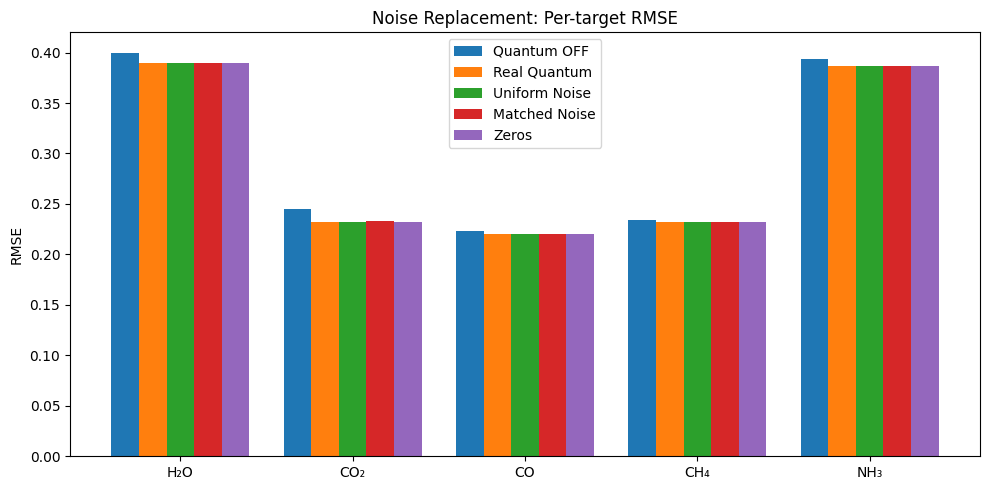

In [6]:
fig = plot_per_target(results, "Noise Replacement: Per-target RMSE")
plt.show()

In [7]:
# Interpretation
real_mrmse = results["Real Quantum"]["rmse_mean"]
noise_mrmse = results["Uniform Noise"]["rmse_mean"]
off_mrmse = results["Quantum OFF"]["rmse_mean"]
zeros_mrmse = results["Zeros"]["rmse_mean"]

print("=== Noise Replacement Interpretation ===")
print(f"Quantum OFF:     {off_mrmse:.4f}")
print(f"Real Quantum:    {real_mrmse:.4f} (delta from OFF: {real_mrmse - off_mrmse:+.4f})")
print(f"Uniform Noise:   {noise_mrmse:.4f} (delta from OFF: {noise_mrmse - off_mrmse:+.4f})")
print(f"Zeros:           {zeros_mrmse:.4f} (delta from OFF: {zeros_mrmse - off_mrmse:+.4f})")

if real_mrmse < noise_mrmse - 0.001:
    print("\nVERDICT: Real quantum output is BETTER than noise — circuit provides useful signal.")
elif abs(real_mrmse - noise_mrmse) < 0.001:
    print("\nVERDICT: Real quantum ≈ noise — circuit signal indistinguishable from random features.")
else:
    print("\nVERDICT: Real quantum is WORSE than noise — circuit may be actively harmful.")

=== Noise Replacement Interpretation ===
Quantum OFF:     0.2993
Real Quantum:    0.2922 (delta from OFF: -0.0070)
Uniform Noise:   0.2923 (delta from OFF: -0.0070)
Zeros:           0.2923 (delta from OFF: -0.0070)

VERDICT: Real quantum ≈ noise — circuit signal indistinguishable from random features.


In [8]:
# Also test on holdout
print("\n=== Holdout Set ===")
holdout_results = {}
holdout_results["Quantum OFF"] = evaluate(model, data.holdout, data.target_scaler, enable_quantum=False)
holdout_results["Real Quantum"] = evaluate(model, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)

# Uniform noise on holdout
trial_mrmses = []
for trial in range(N_TRIALS):
    model.quantum_block.forward = lambda self_or_input: replace_with_uniform(model.quantum_block, self_or_input)
    m = evaluate(model, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
    trial_mrmses.append(m["rmse_mean"])
del model.quantum_block.forward

print(f"Quantum OFF:   {holdout_results['Quantum OFF']['rmse_mean']:.4f}")
print(f"Real Quantum:  {holdout_results['Real Quantum']['rmse_mean']:.4f}")
print(f"Uniform Noise: {np.mean(trial_mrmses):.4f} ± {np.std(trial_mrmses):.4f}")


=== Holdout Set ===
Quantum OFF:   0.3024
Real Quantum:  0.2956
Uniform Noise: 0.2957 ± 0.0000
